# **Instructor Effectiveness Modeling (EdTech Context)**

## Part 3: Aggregation of Batch Data to Instructor Level

Rolling 2000 batch rows up to 120 instructors, then defining the weighted effectiveness score and the Low / Medium / High tiers.

**Notebooks in this project:**

1. `01_Data_Ingestion_and_Preparation.ipynb`
2. `02_Data_Interpretation_and_EDA.ipynb`
3. `03_Instructor_Level_Aggregation.ipynb` &nbsp;&larr; *you are here*
4. `04_Machine_Learning_Model.ipynb`
5. `05_Model_Evaluation.ipynb`
6. `06_Interpretation_and_Analysis_Questions.ipynb`

---

> **Setup cell (added when the original single notebook was split).** Run this first so the notebook works standalone.


In [ ]:
# --- Setup: re-load the raw data (this notebook continues from Part 2) ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = r'C:\\Users\\acer\\Desktop\\Programs\\Accredian-Assignment\\data\\instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv'
ARTIFACTS = 'artifacts'          # shared folder used to hand data to the next notebook
os.makedirs(ARTIFACTS, exist_ok=True)

data = pd.read_csv(DATA_PATH)
data.shape

---

# **Part3: Aggregation fo Batch Data to Instructor Level**

---

In [97]:
# Importing some more machine learning  libraries:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

**Aggregation approach:**
* For each of the 9 numeric metrics, we take the **mean per instructor** — since every instructor already has a reasonably large sample of batches (≥7, median 17), the mean is a stable, low-noise summary of typical performance.
* We also compute the **standard deviation per metric** per instructor, to capture *consistency* — an instructor who averages a high completion rate but has wildly inconsistent batches is arguably less "reliably effective" than one who is consistently good.
* We keep `batch_count` (number of batches taught) as an extra feature, in case the model finds that experience level (more batches taught) relates to effectiveness.


**Handling instructors with few vs. many batches:**
* Since the minimum batch count in this dataset is 7 (no instructor has just 1–2 batches), we do **not** need to drop or heavily down-weight anyone — a plain mean is statistically defensible for all 120 instructors.
* If the data *did* include instructors with very few batches (e.g., 1–2), the safer approach would be either (a) requiring a minimum batch-count threshold before including an instructor in modeling, or (b) using a shrinkage/empirical-Bayes estimate that pulls low-sample instructors' averages toward the overall mean, so a single lucky/unlucky batch doesn't distort their score. We call this out here as good practice even though it isn't strictly required for this dataset.

In [98]:
#Making an metrics column for the data:
metric_cols = ['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
               'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
               'avg_feedback_score', 'feedback_response_rate']

In [99]:
# Creating a dataframe for the instructor:
# Mean per instructor for each metric
instructor_df = data.groupby('instructor_id')[metric_cols].mean()

# Standard deviation per instructor for each metric (consistency signal), suffixed '_std'
std_df = data.groupby('instructor_id')[metric_cols].std().add_suffix('_std').fillna(0)

# Number of batches taught
instructor_df['batch_count'] = data.groupby('instructor_id').size()

instructor_df = instructor_df.join(std_df)
instructor_df.head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count,completion_rate_std,avg_score_improvement_std,avg_quiz_score_std,dropout_rate_std,avg_watch_time_std,assignment_submission_rate_std,forum_activity_rate_std,avg_feedback_score_std,feedback_response_rate_std
instructor_id,,,,,,,,,,,,,,,,,,,
I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,25,0.084611,6.074232,8.878089,0.087671,0.131532,0.145189,0.094695,0.388802,0.166455
I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,20,0.103691,3.939007,9.843168,0.098811,0.112701,0.141096,0.088573,0.440235,0.114460
I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,18,0.120452,5.074705,11.064673,0.115966,0.158280,0.121712,0.082414,0.386108,0.141805
I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,17,0.067596,4.826162,12.485520,0.083598,0.126603,0.135790,0.093217,0.400982,0.133622
I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,19,0.090287,4.621194,7.228742,0.097634,0.108567,0.102360,0.105278,0.304174,0.127054


# *Define Instructor Effectiveness Score & Tiers**

**Assumptions & definition:**
There's no single "correct" formula, so we build a transparent, justifiable **weighted composite score**:

1. **Min-max normalize** every metric to a 0–1 scale, so metrics with different units/ranges (e.g., quiz score 0–100 vs. completion rate 0–1) contribute fairly.
2. **Invert `dropout_rate`** (`1 - normalized_dropout`), since lower dropout is better — we want every normalized column to point in the "higher is better" direction.
3. **Assign weights** based on how directly each metric reflects effectiveness, grouped by category:
   * **Outcome metrics** (most directly tied to learning results) get the highest weight: `completion_rate` (0.20), `dropout_rate` (0.15), `avg_quiz_score` (0.15), `avg_score_improvement` (0.15) → **65% total**.
   * **Engagement metrics** (leading indicators, but indirect) get moderate weight: `avg_watch_time` (0.10), `assignment_submission_rate` (0.10) → **20% total**.
   * **Satisfaction metrics** get the lowest weight, since they're subjective and self-reported: `avg_feedback_score` (0.10), `feedback_response_rate` (0.03), `forum_activity_rate` (0.02) → **15% total**.
4. The final **`effectiveness_score`** is the weighted sum of these normalized metrics (weights sum to 1.0).

**Tier classification:** We convert the continuous score into **Low / Medium / High** tiers using **tertile (33/33/33) cutoffs** (`pd.qcut`) rather than fixed thresholds. This is a deliberate, data-driven choice: it guarantees a **balanced class distribution**.

In [100]:
norm = instructor_df[metric_cols].copy()
scaler_score = MinMaxScaler()
norm[metric_cols] = scaler_score.fit_transform(norm[metric_cols])
norm['dropout_rate'] = 1 - norm['dropout_rate']  # invert: lower dropout = better

In [101]:

weights = {
    'completion_rate': 0.20,
    'dropout_rate': 0.15,
    'avg_quiz_score': 0.15,
    'avg_score_improvement': 0.15,
    'avg_watch_time': 0.10,
    'assignment_submission_rate': 0.10,
    'avg_feedback_score': 0.10,
    'feedback_response_rate': 0.03,
    'forum_activity_rate': 0.02,
}

In [102]:
assert abs(sum(weights.values()) - 1.0) < 1e-9

instructor_df['effectiveness_score'] = sum(norm[c] * w for c, w in weights.items())
instructor_df['effectiveness_tier'] = pd.qcut(instructor_df['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High'])

instructor_df[['effectiveness_score', 'effectiveness_tier']].head()

,effectiveness_score,effectiveness_tier
instructor_id,,
I_001,0.446175,Medium
I_002,0.678648,High
I_003,0.700153,High
I_004,0.363421,Low
I_005,0.810009,High


C:\Users\acer\AppData\Local\Temp\ipykernel_2188\2968461721.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_counts.index, y=tier_counts.values, ax=axes[1], palette='viridis')


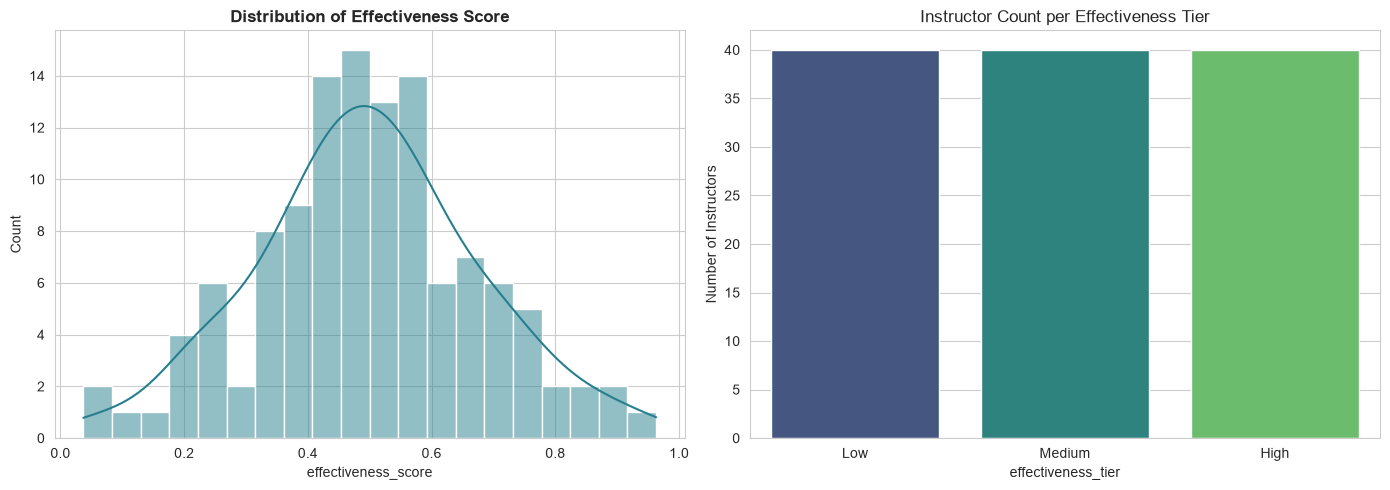

In [103]:
# Plotting the effectiveness scorea and tier:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(instructor_df['effectiveness_score'], bins=20, kde=True, ax=axes[0], color=sns.color_palette('viridis')[2])
axes[0].set_title('Distribution of Effectiveness Score', fontweight='bold')

tier_counts = instructor_df['effectiveness_tier'].value_counts().reindex(['Low', 'Medium', 'High'])
sns.barplot(x=tier_counts.index, y=tier_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Instructor Count per Effectiveness Tier')
axes[1].set_ylabel('Number of Instructors')

plt.tight_layout()
plt.show()

## Efeectiveness tier: perfromed quantile cuts of 3 on the instructors.
 
* Low       40
* Medium    40
* High      40

# **Result: The tertile split produces 40 instructors in each of Low, Medium, and High**,

Seems we have balanced the data and there is nothing like any imbalance till now.

---

### Saving the instructor-level table for the next notebook

`instructor_df` is the input for the modelling step, so we write it to disk and
`04_Machine_Learning_Model.ipynb` reads it back.

In [ ]:
instructor_df.to_csv(os.path.join(ARTIFACTS, 'instructor_level_data.csv'))
print('Saved ->', os.path.join(ARTIFACTS, 'instructor_level_data.csv'), instructor_df.shape)